# Text pre-processing

### Loading the file containing all the tracks.

In [18]:
import json

with open('dataset/tracks_lyrics_preprocessed.json', 'r', encoding='utf-8') as file:
    artists = json.load(file)

corpus = []

for artist in artists:
    for track in artist.get('tracks', []):
        
        clean_text = track.get('lemmatized_lyrics', '')
        corpus.append(clean_text)   
    
print(artists[0]["artist_id"], "\n", 
      artists[0]["artist_name"], "\n", 
      artists[0]['tracks'][0]['title'], "\n", 
      artists[0]['tracks'][0]['lyrics'][:100].lstrip(), "...", 
      sep="")

582KhTHEVOONNQLmQ5612r
Calcutta 
Tutti
Ho messo le scarpe nuove per i giorni di fango
Forse i leghisti lì in riva al Po non hanno più un ca...


# Text representation

### Feature Extraction: BoW and TF-IDF

**scikit-learn** is an industry-standard machine learning library for Python. Once our text has been cleaned, tokenized, and lemmatized by Stanza, it remains in a string format. However, Machine Learning algorithms cannot process raw text; they require numerical inputs. To bridge this gap, we rely on scikit-learn to perform **vectorization**, converting our linguistic corpus into structured mathematical matrices.

Before generating these matrices, we must define **statistical thresholds** to filter out noise. Even after discarding structural stop-words during the Stanza pipeline, a corpus often contains domain-specific clutter or rare anomalies that add computational weight without predictive value. We handle this using document frequency boundaries:

* **`max_df=0.75` (Maximum Document Frequency):** this threshold aggressively removes terms that appear in more than 75% of the tracks. In a musical context, for example, overly ubiquitous words like 'amore' or 'cuore' lose their discriminative power. Because they appear almost everywhere, they act as domain-specific stop-words and are discarded.
* **`min_df=0.01` (Minimum Document Frequency):** conversely, this discards words that appear in fewer than 1% of the tracks. This step effectively purges our matrices of rare typos, highly idiosyncratic slang, or single-use terms that would only inflate the matrix's dimensionality without improving the model's accuracy.

Here is a breakdown of our vectorization process:

* **`CountVectorizer` (Bag-of-Words):** this tool scans the processed corpus and tallies the absolute frequency of each retained lemma. The result is a high-dimensional Bag-of-Words (BoW) matrix where rows represent individual documents (tracks) and columns represent the discrete frequency of our filtered vocabulary. 
* **`TfidfVectorizer` (TF-IDF):** while BoW counts absolute occurrences, Term Frequency-Inverse Document Frequency (TF-IDF) weighs them. It diminishes the weight of terms that appear frequently across the entire corpus while boosting the weight of terms that are highly specific to individual documents. This highlights the unique thematic footprint of each track.

#### Methodological Note
It is crucial to highlight a specific architectural choice in our code: we initialize the `TfidfVectorizer` using `vocabulary=bow_vectorizer.vocabulary_`. 
By forcing the TF-IDF matrix to inherit the exact same feature space learned by the BoW vectorizer, we guarantee that both matrices possess identical dimensions and identical columns. This strict consistency is a best practice, ensuring seamless interoperability and preventing dimensional mismatches when feeding these matrices into downstream Machine Learning models for comparative analysis.

In [2]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# STATISTICAL THRESHOLDS
# max_df = 0.75: Discard words appearing in > 50% of tracks (Domain-specific stop-words are too common to be informative)
# min_df = 0.01: Discard words appearing in < 1% of tracks (Rare typos, extremely specific slang)
MAX_DF_THRESHOLD = 0.75
MIN_DF_THRESHOLD = 0.01

print("--- 1. BAG OF WORDS (BoW) GENERATION ---")
# Initialize the BoW vectorizer
bow_vectorizer = CountVectorizer(max_df=MAX_DF_THRESHOLD, min_df=MIN_DF_THRESHOLD)
# Fit and transform the Stanza-processed corpus
bow_matrix = bow_vectorizer.fit_transform(corpus)
print(f"BoW Matrix shape: {bow_matrix.shape} (Documents, Features)")


print("\n--- 2. TF-IDF GENERATION ---")
# We initialize the TF-IDF matrix using the vocabulary learned by the BoW vectorizer.
tfidf_vectorizer = TfidfVectorizer(vocabulary=bow_vectorizer.vocabulary_)
# Transform the corpus into weighted TF-IDF values
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)
# Extract the final useful vocabulary to verify
useful_features = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF Matrix shape: {tfidf_matrix.shape} (Documents, Features)")
# Check
print(f"\nSample of useful features retained: {list(useful_features)[100:110]}")

--- 1. BAG OF WORDS (BoW) GENERATION ---
BoW Matrix shape: (20616, 1191) (Documents, Features)

--- 2. TF-IDF GENERATION ---
TF-IDF Matrix shape: (20616, 1191) (Documents, Features)

Sample of useful features retained: ['basso', 'bastardo', 'bastare', 'battere', 'battito', 'beat', 'bellezza', 'bello', 'bene', 'bere']


# Topic Modeling

### High-Performance Topic Model Evaluation: Grid Search and Custom Metrics

Finding the optimal number of topics ($K$) in Machine Learning is rarely an exact science; it requires empirical testing. To determine the most effective mathematical approach for our specific corpus, we implement a **Grid Search** evaluating three distinct dimensionality reduction algorithms LDA, NMF, and LSA across a range of $K$ values (from 3 to 10). 

Because unsupervised learning lacks a definitive "ground truth" to measure against, we cannot rely on standard accuracy metrics. Instead, we must evaluate the quality of the generated topics using two custom natural language metrics:

* **Topic Diversity:** A model might achieve high coherence by generating multiple identical topics, which provides no analytical value. Diversity counters this by calculating the proportion of unique words across all top words extracted by the model. 
  $$\text{Diversity} = \frac{|\text{Unique Words}|}{\text{Total Words extracted}}$$
  A score closer to **1.0** indicates that the model successfully separated distinct concepts without overlapping vocabularies.

* **UMass Topic Coherence:** This metric measures the semantic quality of a topic by checking how often its top words actually co-occur in the same documents. It operates under the assumption that words belonging to a coherent concept will frequently appear together in the original text. The algorithm computes the co-document frequency $D(w_i, w_j)$ of word pairs, applying smoothing to prevent mathematical errors. The formula is expressed as:
  $$C_{UMass} = \sum_{i>j} \log \left( \frac{D(w_i, w_j) + 1}{D(w_j)} \right)$$
  Because it calculates a logarithmic penalty for words that rarely co-occur, the resulting score is strictly negative. A score **closer to 0** indicates higher semantic coherence.

Here is a breakdown of the algorithms evaluated in our parallelized pipeline:

* **`LDA` (Latent Dirichlet Allocation):** a generative probabilistic model. It fundamentally assumes that documents are random mixtures over latent topics, and topics are distributions over words. Because it relies on discrete probability distributions, **LDA must be fed the absolute integers of the BoW matrix**, not the continuous weights of TF-IDF.
* **`NMF` (Non-Negative Matrix Factorization):** a linear algebraic model that factors high-dimensional vectors into a lower-dimensional space, strictly enforcing positive values. This additive nature makes the topics highly interpretable. NMF excels when fed the weighted, continuous values of our **TF-IDF matrix**.
* **`LSA` (Latent Semantic Analysis / TruncatedSVD):** A classic algebraic dimensionality reduction technique. While it does not enforce non-negativity (meaning terms can have negative associations with a topic), it is highly efficient at capturing variance. Like NMF, it utilizes the **TF-IDF matrix**.

#### Architectural Note
Topic modeling is computationally expensive. Running three algorithms across eight different $K$ configurations sequentially would be incredibly slow. To solve this, we leverage the **`joblib`** library. By wrapping our evaluation function in `Parallel(n_jobs=-1)`, we command Python to bypass the Global Interpreter Lock (GIL) and distribute the training tasks concurrently across 100% of the available CPU cores. Furthermore, we pre-calculate a binary boolean mask of our BoW matrix before launching the parallel workers; this drastically accelerates the matrix dot-products required for the UMass Coherence calculations.

Finally, to make sense of this multidimensional evaluation and objectively determine the best model using intrinsic metrics, we pass the results to **Plotly**. This generates an interactive, colorblind-friendly dashboard that allows us to visually balance the trade-off between Coherence and Diversity to make our final selection.

**Bibliographic reference (UMass Coherence):**
> Mimno, D., Wallach, H., Talley, E., Leenders, M., & McCallum, A. (2011). **Optimizing semantic coherence in topic models**. In *Proceedings of the 2011 conference on empirical methods in natural language processing* (pp. 262-272).

In [3]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from joblib import Parallel, delayed
from sklearn.decomposition import LatentDirichletAllocation, NMF, TruncatedSVD

print("Initializing High-Performance Parallel Topic Model Evaluator...")

# CONFIGURATION
# Define the range of 'K' (number of topics) to test
TOPIC_RANGE = [3, 4, 5, 6, 7, 8, 9, 10]
ALGORITHMS = ['LDA', 'NMF', 'LSA']
NO_TOP_WORDS = 10 # Number of words to evaluate for Coherence and Diversity

# Pre-calculate a binary Document-Term matrix. 
binary_bow_matrix = (bow_matrix > 0).astype(int)

# CUSTOM EVALUATION METRICS 
def calculate_diversity(topic_words_list):
    """
    Calculates Topic Diversity.
    Formula: (Number of unique words across all topics) / (Total words extracted)
    Range: 0.0 to 1.0 (Higher is better)
    """
    all_words = []
    for words in topic_words_list:
        all_words.extend(words)
    unique_words = set(all_words)
    return len(unique_words) / len(all_words)

def calculate_umass_coherence(topic_words_indices, binary_matrix):
    """
    Calculates UMass Coherence directly from the binary Bag of Words matrix.
    It checks how often the top words co-occur in the actual lyrics.
    (Closer to 0 is better, highly negative means poor coherence).
    """
    coherence_score = 0.0
    num_topics = len(topic_words_indices)
    
    for word_indices in topic_words_indices:
        topic_score = 0.0
        # Iterate over all word pairs (w_i, w_j) in the top words
        for i in range(1, len(word_indices)):
            for j in range(i):
                w_i = word_indices[i]
                w_j = word_indices[j]
                
                # Document frequency of w_j
                doc_freq_j = binary_matrix[:, w_j].sum()
                # Co-document frequency of w_i and w_j
                # Using sparse matrix dot product for speed
                co_doc_freq = binary_matrix[:, w_i].T.dot(binary_matrix[:, w_j])[0, 0]
                
                # UMass formula with +1 smoothing to avoid log(0)
                if doc_freq_j > 0:
                    topic_score += np.log((co_doc_freq + 1.0) / doc_freq_j)
                    
        coherence_score += topic_score
        
    return coherence_score / num_topics

# PARALLEL WORKER FUNCTION
def train_and_evaluate(algo_name, k, bow_mat, tfidf_mat, feature_names, binary_mat):
    """
    This is the core function that will be shipped to each CPU thread.
    """
    # Initialize the correct model based on the name
    if algo_name == 'LDA':
        model = LatentDirichletAllocation(n_components=k, random_state=42, max_iter=10)
        matrix_to_use = bow_mat # LDA must use BoW
    elif algo_name == 'NMF':
        model = NMF(n_components=k, random_state=42, init='nndsvd', max_iter=200)
        matrix_to_use = tfidf_mat # NMF uses TF-IDF
    elif algo_name == 'LSA':
        model = TruncatedSVD(n_components=k, random_state=42)
        matrix_to_use = tfidf_mat # LSA uses TF-IDF
        
    # Train the model
    model.fit(matrix_to_use)
    
    # Extract top words indices for metrics
    topic_words_indices = []
    topic_words_strings = []
    
    for topic in model.components_:
        # Get top indices
        top_indices = topic.argsort()[:-NO_TOP_WORDS - 1:-1]
        topic_words_indices.append(top_indices)
        
        # Get top actual string words for diversity
        top_strings = [feature_names[i] for i in top_indices]
        topic_words_strings.append(top_strings)
        
    # Calculate Custom Metrics
    diversity = calculate_diversity(topic_words_strings)
    coherence = calculate_umass_coherence(topic_words_indices, binary_mat)
    
    # Return a dictionary of results for this specific run
    return {
        'Algorithm': algo_name,
        'K_Topics': k,
        'Diversity': round(diversity, 3),
        'Coherence': round(coherence, 3)
    }

# EXECUTE PARALLEL GRID SEARCH 
print(f"Distributing tasks across all CPU cores (n_jobs=-1)...")
# Build the task list
tasks = [(algo, k) for algo in ALGORITHMS for k in TOPIC_RANGE]

# Run the tasks in parallel
# n_jobs=-1 tells joblib to use 100% of available CPU cores
results = Parallel(n_jobs=-1, verbose=0)(
    delayed(train_and_evaluate)(
        algo, k, bow_matrix, tfidf_matrix, useful_features, binary_bow_matrix
    ) for algo, k in tasks
)

# Convert results to a clean Pandas DataFrame for easy reading
df_results = pd.DataFrame(results)
print("\n" + "="*50)
print("              EVALUATION COMPLETED")
print("="*50)
print(df_results.sort_values(by=['Algorithm', 'K_Topics']).to_string(index=False))


# VISUALIZE THE RESULTS (Plotly)
print("\nGenerazione della dashboard interattiva...")

# Colorblind-Friendly palette
colors = {'LDA': '#0072B2', 'NMF': '#E69F00', 'LSA': '#CC79A7'}

# Initialize a figure with two side-by-side subplots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'UMass Topic Coherence<br><sub>(Closer to 0 is better)</sub>', 
        'Topic Diversity<br><sub>(Closer to 1.0 is better)</sub>'
    ),
    horizontal_spacing=0.1
)

# Populate the subplots with lines and markers for each algorithm
for algo in ALGORITHMS:
    subset = df_results[df_results['Algorithm'] == algo]
    
    # Graph 1: Coherence
    fig.add_trace(go.Scatter(
        x=subset['K_Topics'], 
        y=subset['Coherence'],
        mode='lines+markers',
        name=algo,
        line=dict(color=colors[algo], width=2),
        marker=dict(symbol='circle', size=8),
        legendgroup=algo,
        hovertemplate="<b>%{text}</b><br>K: %{x}<br>Coherence: %{y:.3f}<extra></extra>",
        text=[algo] * len(subset)
    ), row=1, col=1)
    
    # Graph 2: Diversity
    fig.add_trace(go.Scatter(
        x=subset['K_Topics'], 
        y=subset['Diversity'],
        mode='lines+markers',
        name=algo,
        line=dict(color=colors[algo], width=2, dash='dash'),
        marker=dict(symbol='square', size=8),
        legendgroup=algo,
        showlegend=False, 
        hovertemplate="<b>%{text}</b><br>K: %{x}<br>Diversity: %{y:.3f}<extra></extra>",
        text=[algo] * len(subset)
    ), row=1, col=2)

fig.update_layout(
    title_text="Topic Model Evaluation Results",
    title_font_size=20,
    height=600,
    template="plotly_white",
    legend=dict(
        title="Algorithms",
        yanchor="top", y=0.99,
        xanchor="left", x=1.02
    ),
    hovermode="x unified"
)

# Axes Labels
fig.update_xaxes(title_text="Number of Topics (K)", tickmode='linear', dtick=1, row=1, col=1)
fig.update_xaxes(title_text="Number of Topics (K)", tickmode='linear', dtick=1, row=1, col=2)

fig.update_yaxes(title_text="Coherence Score", row=1, col=1)
fig.update_yaxes(title_text="Diversity Score (Proportion of unique words)", row=1, col=2)

# Show the interactive plot
fig.show()

Initializing High-Performance Parallel Topic Model Evaluator...
Distributing tasks across all CPU cores (n_jobs=-1)...


/home/gabriele11231/.venvs/rapids25.06_python3.12/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gabriele11231/.venvs/rapids25.06_python3.12/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gabriele11231/.venvs/rapids25.06_python3.12/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gabriele11231/.venvs/rapids25.06_python3.12/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(



              EVALUATION COMPLETED
Algorithm  K_Topics  Diversity  Coherence
      LDA         3      0.600    -37.109
      LDA         4      0.575    -37.364
      LDA         5      0.540    -39.999
      LDA         6      0.600    -42.818
      LDA         7      0.600    -46.675
      LDA         8      0.613    -50.192
      LDA         9      0.578    -50.485
      LDA        10      0.590    -50.819
      LSA         3      0.767    -58.693
      LSA         4      0.725    -62.356
      LSA         5      0.600    -72.841
      LSA         6      0.567    -65.058
      LSA         7      0.471    -73.654
      LSA         8      0.438    -70.842
      LSA         9      0.456    -73.111
      LSA        10      0.410    -68.632
      NMF         3      0.867    -55.113
      NMF         4      0.875    -61.993
      NMF         5      0.880    -68.968
      NMF         6      0.867    -59.518
      NMF         7      0.800    -61.041
      NMF         8      0.787    -61.19

### Topic Extraction and Interpretation: Implementing NMF

Once the optimal number of topics has been identified through our grid search evaluation, we can proceed with the final extraction. For this phase, we isolate **Non-Negative Matrix Factorization (NMF)** as our primary algorithm. 

NMF is a powerful linear algebraic method that approximates our high-dimensional TF-IDF matrix ($V$) by factoring it into two lower-dimensional matrices.

Because NMF enforces a strict non-negativity constraint ($W \ge 0, H \ge 0$), it does not allow for subtractive relationships. Topics are constructed purely by *adding* semantic parts together. This additive property mirrors how human language naturally constructs meaning, making NMF topics highly interpretable.

Here is a methodological breakdown of the code:

* **Hyperparameter Selection:** we define `NUM_TOPICS = 6` (our $K$ dimensionality) as the empirical baseline for our specific domain, alongside `NO_TOP_WORDS = 10` to restrict our analytical focus to the most dominant features of each latent topic.
* **Deterministic Initialization (`init='nndsvd'`):** instead of initializing the matrices with random noise, we use Nonnegative Double Singular Value Decomposition (NNDSVD). This is a specialized initialization technique designed explicitly for sparse matrices (like our TF-IDF matrix). It guarantees deterministic results (the same output every run, regardless of the random seed) and drastically accelerates mathematical convergence.
* **The Extraction Logic (`model.components_`):** in scikit-learn, the `components_` attribute corresponds to the $H$ matrix (the topic-term matrix). Its shape is exactly $K \times N$ (Number of Topics $\times$ Vocabulary Size). Each row represents a topic, and each column contains the specific weight of a word within that topic.
* **Sorting and Mapping (`argsort`):** because the $H$ matrix only contains numerical weights, the `display_topics` function leverages NumPy's `argsort()` to rank the indices of these weights in ascending order. By reversing the array and slicing the top $N$ indices, we can map these numbers back to the original string tokens stored in `feature_names`, revealing the human-readable vocabulary that defines each topic.

#### Analytical Note
By simultaneously printing the exact numerical weights alongside the top words, we gain insight into the *distribution* of a topic. A topic where the top word has a weight of $2.5$ while the second has $0.3$ is heavily anchored to a single concept. Conversely, a topic with smoothly decaying weights (e.g., $1.2, 1.1, 0.9$) indicates a broader, more nuanced semantic theme.


In [4]:
# HYPERPARAMETERS
# The number of topics to extract
NUM_TOPICS = 6
# How many top words to display to interpret the meaning of each topic
NO_TOP_WORDS = 10 

# ==========================================
# NON-NEGATIVE MATRIX FACTORIZATION (NMF)
# ==========================================
print("\n--- NMF (TF-IDF) ---")
nmf_model = NMF(n_components=NUM_TOPICS, random_state=42, init='nndsvd')
nmf_model.fit(tfidf_matrix)

# DISPLAY FUNCTION 
def display_topics(model, feature_names, no_top_words):
    """
    Helper function to print the top features (words) for each extracted topic.
    For LSA, weights can be negative, showing words that 'repel' the topic.
    """
    for topic_idx, topic in enumerate(model.components_):
        # Sort weights in ascending order and slice the top N words
        top_words_indices = topic.argsort()[:-no_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_indices]
        
        # Calculate rounded weights for analysis
        top_weights = [round(topic[i], 2) for i in top_words_indices]
        
        print(f"Topic {topic_idx + 1}:")
        print(" | ".join(top_words))
        print(f"Weights: {top_weights}\n")

# Retrieve the vocabulary (features) generated during vectorization
feature_names = bow_vectorizer.get_feature_names_out()

# PRINTING THE RESULTS 
print("\n" + "="*50)
print("              NMF RESULTS")
print("="*50)
display_topics(nmf_model, feature_names, NO_TOP_WORDS)




--- NMF (TF-IDF) ---

              NMF RESULTS
Topic 1:
più | solo | mai | ancora | sempre | giorno | notte | mondo | qui | sentire
Weights: [2.1, 1.03, 0.85, 0.81, 0.75, 0.75, 0.74, 0.72, 0.71, 0.71]

Topic 2:
amore | amare | cuore | bello | morire | fiore | dolce | donna | cantare | grande
Weights: [3.33, 0.72, 0.59, 0.34, 0.29, 0.24, 0.22, 0.19, 0.19, 0.19]

Topic 3:
avere | soldo | stare | cazzo | chiamare | mettere | prendere | solo | amico | casa
Weights: [2.06, 0.92, 0.86, 0.73, 0.72, 0.67, 0.61, 0.61, 0.6, 0.58]

Topic 4:
sapere | dire | mai | amare | stare | pensare | solo | già | anche | cosa
Weights: [3.21, 1.49, 0.85, 0.71, 0.42, 0.4, 0.32, 0.32, 0.3, 0.3]

Topic 5:
volere | tenere | nun | cchiù | mo | aggio | pecché | ancora | pure | vita
Weights: [2.34, 0.94, 0.9, 0.86, 0.73, 0.62, 0.58, 0.46, 0.45, 0.42]

Topic 6:
andare | bene | via | così | dove | mare | stare | venire | lasciare | dire
Weights: [3.05, 0.93, 0.73, 0.53, 0.49, 0.37, 0.35, 0.28, 0.27, 0.26]



### Neural Topic Modeling: Building a VAE with PyTorch

While algorithms like LDA and NMF are excellent, Deep Learning allows us to capture much more complex relationships in text. In this section, we transition to **PyTorch** to build a neural model based on the **Variational Autoencoder (VAE)** architecture.

Here is a breakdown of the logical steps and key implementation choices behind our code:

* **1. Strict Reproducibility (The "Seeds"):** Neural networks on GPUs are inherently chaotic and stochastic. To ensure the model produces *exactly the same topics* every time we run the notebook, we locked down every single source of randomness (fixing the seeds for NumPy, PyTorch, and CUDA). This is crucial for scientifically valid results.
* **2. Hyperparameter Alignment (Why 6 Topics?):** You will notice we explicitly set `NUM_TOPICS = 6`. We chose this specific number because it was identified as the optimal value for NMF during our earlier Grid Search evaluation. By keeping the dimensionality identical, we establish a level playing field, allowing us to directly and fairly compare the semantic quality of traditional linear algebra (NMF) versus Deep Learning (VAE).
* **3. The architecture (encoder & decoder):**
  * **The encoder** takes our text and compresses it into a smaller "latent space." Instead of turning a document into a simple vector of numbers, it transforms it into a *probability distribution*. This makes the model much more flexible and robust when handling ambiguous words.
  * **The decoder** does the exact opposite: it takes these compressed concepts and tries to reconstruct the original words. **Key implementation choice:** the "weights" the decoder uses to rebuild the words act, functionally, as our topic matrix! By extracting these weights at the end of training, we can read our human-interpretable topics.
* **4. The Loss Function (The Balancing Act):** The model learns by trying to minimize an error metric called the ELBO. Essentially, it does two things simultaneously: it tries to reconstruct the original text as accurately as possible, but at the same time, it "restricts" itself (regularization) to prevent the network from simply memorizing the dataset.
* **5. Smart Training (Early Stopping):** How long should the network train? Instead of guessing a fixed number of "epochs," we implemented an *Early Stopping* mechanism. The model monitors itself: if it fails to improve for 10 consecutive cycles, it stops automatically and recovers its best saved state. This saves precious GPU time and prevents overfitting.

#### Core Implementation Choice: Why BoW and not TF-IDF?
We loaded the **Bag-of-Words (BoW)** matrix into the neural network, whereas we used TF-IDF for NMF. This is not a mistake, but a deliberate architectural choice. Neural models like this are probabilistic generative models: they need to "count" actual word occurrences (discrete integers). Feeding them the fractional, continuous weights of a TF-IDF matrix would violate the mathematical rules they are built upon, severely degrading the quality of the extracted topics.

**Bibliographic reference (Neural Topic Models):**
> Srivastava, A., & Sutton, C. (2017). Autoencoding variational inference for topic models. arXiv preprint arXiv:1703.01488.

In [5]:
import torch
import copy
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Fix randomness everywhere to guarantee identical results on every run
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    # Enforce deterministic algorithms on the GPU (may slightly impact performance)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# PREPARE THE DATA FOR PYTORCH
# Convert the sparse bow_matrix from Scikit-Learn into a dense PyTorch Tensor
# Neural networks require floating point inputs for gradient descent
X_train = torch.tensor(bow_matrix.toarray(), dtype=torch.float32)
vocab_size = X_train.shape[1]
num_documents = X_train.shape[0]

# Create a fast PyTorch DataLoader to handle batching internally
batch_size = 64
dataset = TensorDataset(X_train)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


# VARIATIONAL AUTOENCODER ARCHITECTURE (AVITM Style)
class NeuralTopicModel(nn.Module):
    def __init__(self, vocab_size, num_topics, hidden_dim=100):
        super(NeuralTopicModel, self).__init__()
        
        # ENCODER: Maps Bag of Words to Latent Space Parameters (Mean and Variance)
        self.encoder = nn.Sequential(
            nn.Linear(vocab_size, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # Latent representations for the Gaussian distribution
        self.fc_mu = nn.Linear(hidden_dim, num_topics)
        self.fc_logvar = nn.Linear(hidden_dim, num_topics)
        
        # DECODER: Reconstructs the Bag of Words from the Topic Distribution
        # Softmax ensures the weights form a valid probability distribution over words
        self.decoder = nn.Linear(num_topics, vocab_size, bias=False)
        self.softmax = nn.Softmax(dim=1)
        
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        """
        The Reparameterization Trick: Allows backpropagation through stochastic nodes
        by sampling noise from a standard normal distribution.
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        # Apply softmax to latent space to match ProdLDA's logisticnormal distribution
        theta = self.softmax(z)
        # Reconstruct word probabilities
        return torch.log(self.softmax(self.decoder(theta)) + 1e-10)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# LOSS FUNCTION (ELBO)
def loss_function(recon_x, x, mu, logvar):
    """
    Evidence Lower Bound (ELBO): Minimizes reconstruction error (Cross Entropy)
    while regularizing the latent space via Kullback-Leibler (KL) Divergence.
    """
    # Multinomial reconstruction loss
    recon_loss = -(x * recon_x).sum(dim=1).mean()
    
    # KL Divergence: Forces the encoder to match a standard Normal distribution
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
    
    return recon_loss + kl_loss

# INITIALIZE AND TRAIN THE NEURAL NETWORK
# 1. Increase the number of epochs
NUM_TOPICS = 6
num_epochs = 200 # Set it high, it will stop automatically

model = NeuralTopicModel(vocab_size=vocab_size, num_topics=NUM_TOPICS).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-5)

print(f"Training Neural Topic Model with {NUM_TOPICS} topics on your GPU...")

# EARLY STOPPING INITIALIZATION
best_loss = float('inf')  # Start with an infinite loss
patience = 10              # Number of epochs to wait for improvement
patience_counter = 0      # Counter
best_model_weights = None # We will save the best state here

model.train()
for epoch in range(num_epochs):
    total_loss = 0
    for batch in data_loader:
        inputs = batch[0].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(inputs)
        
        # Calculate ELBO Loss
        loss = loss_function(recon_batch, inputs, mu, logvar)
        
        # Backward pass and optimization step
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    # Calculate the average loss for the epoch
    avg_loss = total_loss / len(data_loader)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Average ELBO Loss: {avg_loss:.4f}")

    # EARLY STOPPING LOGIC
    if avg_loss < best_loss:
        # If the loss improves, update the record and reset the counter
        best_loss = avg_loss
        patience_counter = 0
        # Save a "snapshot" of the current weights using deepcopy
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        # If it doesn't improve, increase the counter
        patience_counter += 1
        
    # If patience runs out, break the loop
    if patience_counter >= patience:
        print(f"\n[!] Early stopping triggered at epoch {epoch+1}!")
        print("Restoring the best weights found...")
        # Load the previously saved snapshot into the model
        model.load_state_dict(best_model_weights)
        break

print("Training completed!")


# EXTRACT TOPIC WORDS FROM THE DECODER WEIGHTS
print("\nExtracting neural network weights to identify topics...")

# The decoder linear weights represent the Topic-to-Word matrix
beta = model.decoder.weight.data.cpu().numpy().T # Shape: (num_topics, vocab_size)
feature_names = bow_vectorizer.get_feature_names_out()

print("\n========================================")
# NEURAL TOPICS RESULTS
print("          NEURAL VAE TOPICS RESULTS")
print("========================================\n")

NO_TOP_WORDS = 10
for topic_idx in range(NUM_TOPICS):
    # Get the indices of the highest weights for this specific neural topic
    top_words_indices = beta[topic_idx].argsort()[:-NO_TOP_WORDS - 1:-1]
    top_words = [feature_names[idx] for idx in top_words_indices]
    top_weights = [round(float(beta[topic_idx][idx]), 3) for idx in top_words_indices]
    
    print(f"Neural Topic {topic_idx + 1}:")
    print(" | ".join(top_words))
    print(f"Decoder Weights: {top_weights}\n")

Using device: cuda
Training Neural Topic Model with 6 topics on your GPU...
Epoch [1/200] - Average ELBO Loss: 685.3378
Epoch [10/200] - Average ELBO Loss: 620.3683
Epoch [20/200] - Average ELBO Loss: 615.7414
Epoch [30/200] - Average ELBO Loss: 615.0269
Epoch [40/200] - Average ELBO Loss: 613.7413
Epoch [50/200] - Average ELBO Loss: 612.8046
Epoch [60/200] - Average ELBO Loss: 612.7690
Epoch [70/200] - Average ELBO Loss: 612.7618
Epoch [80/200] - Average ELBO Loss: 612.7535
Epoch [90/200] - Average ELBO Loss: 611.9734
Epoch [100/200] - Average ELBO Loss: 611.5827
Epoch [110/200] - Average ELBO Loss: 612.0620

[!] Early stopping triggered at epoch 113!
Restoring the best weights found...
Training completed!

Extracting neural network weights to identify topics...

          NEURAL VAE TOPICS RESULTS

Neural Topic 1:
cchiù | aggio | nun | pecché | cu | mo | quanno | tenere | votare | sordo
Decoder Weights: [6.873, 6.576, 6.29, 6.287, 5.525, 5.522, 5.328, 5.171, 5.015, 4.894]

Neural Top

We use the trained neural network to process the lemmatized tracks and categorize each one into one of six distinct topics. While this step seems to be useless, it will be useful for the text classification.

The output includes the following fields:

* **`topic_word`**: The representative keyword associated with the assigned topic, the primary keyword defining the assigned topic.
* **`topic_confidence_%`**: The model's confidence score (as a percentage) for the topic assignment.

In [6]:
print("\nExtracting the most representative word for each neural topic...")

# We map each topic index to its highest-weighted word using the 'beta' matrix
topic_top_words = {}
NUM_TOPICS = beta.shape[0]

for topic_idx in range(NUM_TOPICS):
    # argmax() finds the exact index of the word with the highest weight in the decoder
    top_word_idx = beta[topic_idx].argmax()
    top_word = feature_names[top_word_idx]
    topic_top_words[topic_idx] = top_word
    
    print(f"Topic {topic_idx + 1} represents -> '{top_word.upper()}'")


print("\nStarting song-by-song topic analysis...")

model.eval()

# Loop through each artist in the dataset
for i in range(len(artists)):
    
    # Loop through each track for the current artist
    for j in range(len(artists[i]['tracks'])):
        
        # Extract the clean lyrics
        song_lyrics = artists[i]['tracks'][j]['lemmatized_lyrics']
        
        # Transform the string into a mathematical vector using the fitted vectorizer
        # We use .transform() inside a list to maintain the correct matrix shape
        song_vector = bow_vectorizer.transform([song_lyrics]).toarray()
        
        # Convert the NumPy array into a PyTorch Tensor and send it to the GPU/CPU
        song_tensor = torch.tensor(song_vector, dtype=torch.float32).to(device)
        
        # Neural network inference
        with torch.no_grad():
            mu, logvar = model.encode(song_tensor)
            
            # Apply softmax to get a proper probability distribution (summing to 1.0)
            # We select index [0] because we are only processing one song at a time
            probabilities = model.softmax(mu).cpu().numpy()[0]
            
        # Find the index of the highest probability
        main_topic_idx = int(np.argmax(probabilities))
        
        # Calculate confidence percentage (e.g., 0.854 -> 85.4%)
        confidence = float(np.round(np.max(probabilities) * 100, 2))
        
        # Get the actual word instead of the numeric ID using our dictionary
        assigned_topic_word = topic_top_words[main_topic_idx]
        
        # Save the results directly into the original dictionary structure
        artists[i]['tracks'][j]['topic_word'] = assigned_topic_word
        artists[i]['tracks'][j]['topic_confidence_%'] = confidence


with open("dataset/tracks_lyrics_preprocessed.json", 'w', encoding="utf-8") as json_file:
    json.dump(artists, json_file, ensure_ascii=False, indent=4)

print("Given to all the track their main topic")


Extracting the most representative word for each neural topic...
Topic 1 represents -> 'CCHIÙ'
Topic 2 represents -> 'GANG'
Topic 3 represents -> 'LIBERO'
Topic 4 represents -> 'BALLARE'
Topic 5 represents -> 'AMORE'
Topic 6 represents -> 'SOLO'

Starting song-by-song topic analysis...
Given to all the track their main topic


This phase of the analysis reveals a notable limitation of the neural network: its struggle to fully grasp the semantic nuances and idiomatic flexibility of the Italian language. Because the model lacks human-like contextual comprehension, it occasionally misclassifies tracks that rely heavily on metaphors. 

For instance, the song _"Tutti"_ is assigned to the *ballare* (dance/summer) topic, despite the lyrics actually exploring a nostalgic, unrequited love. Similarly, the track _"Hubner"_ is also miscategorized under the same dance topic. In reality, the song relies on subtle storytelling, using the figure of soccer player Dario Hubner who famously rejected a highly lucrative contract to remain close to his wife as a metaphor for love.

In [10]:
for artist in artists[0:1]:
    for track in artist['tracks'][0:20]:
        print(f"Artist: {artist['artist_name']} | Track: {track['title']} | Assigned Topic: {track['topic_word']} ({track['topic_confidence_%']}% confidence)")

Artist: Calcutta  | Track: Tutti | Assigned Topic: ballare (32.57% confidence)
Artist: Calcutta  | Track: Pesto | Assigned Topic: ballare (34.32% confidence)
Artist: Calcutta  | Track: Cosa mi manchi a fare | Assigned Topic: amore (38.3% confidence)
Artist: Calcutta  | Track: Paracetamolo | Assigned Topic: amore (37.91% confidence)
Artist: Calcutta  | Track: Gaetano | Assigned Topic: ballare (27.11% confidence)
Artist: Calcutta  | Track: Oroscopo | Assigned Topic: ballare (58.28% confidence)
Artist: Calcutta  | Track: Orgasmo | Assigned Topic: libero (22.77% confidence)
Artist: Calcutta  | Track: Controtempo | Assigned Topic: solo (31.53% confidence)
Artist: Calcutta  | Track: Frosinone | Assigned Topic: ballare (27.16% confidence)
Artist: Calcutta  | Track: Sorriso (Milano Dateo) | Assigned Topic: solo (22.56% confidence)
Artist: Calcutta  | Track: Giro con te | Assigned Topic: solo (36.89% confidence)
Artist: Calcutta  | Track: 2minuti | Assigned Topic: solo (47.43% confidence)
Artis

## Comparative Analysis: NMF vs. Neural VAE on Italian Lyrics

This analysis compares the latent semantic structures extracted by Non-Negative Matrix Factorization (NMF) and a Neural Variational Autoencoder (VAE) from a corpus of over 20,000 Italian songs. 

While both models successfully capture broad thematic categories, the **Neural VAE demonstrates a significantly higher capacity to isolate specific musical subgenres, cultural tropes, and modern slang**, whereas NMF tends to cluster around common syntactical structures and high-frequency verbs.

---

### 1. Direct Thematic Alignments

Both algorithms successfully identified the three most dominant pillars of the Italian music corpus: Traditional Romance, Neapolitan dialect, and Urban/Rap music. However, they approach these themes differently.

#### A. The "Classic Love Song" 
* **NMF Topic 2:** *amore, amare, cuore, bello, morire, fiore, dolce...*
* **VAE Topic 5:** *amore, amare, donna, innamorare, bello, volere, cuore...*

**Comparison:** Both models perfectly capture the quintessential Italian pop/love vocabulary. The clusters are nearly identical, showing that romantic terminology is the most statistically dominant and cohesive semantic field in the dataset regardless of the underlying algorithm.

#### B. The Regional / Neapolitan Core
* **NMF Topic 5:** *volere, tenere, nun, cchiù, mo, aggio, pecché...*
* **VAE Topic 1:** *cchiù, aggio, nun, pecché, cu, mo, quanno, tenere...*

**Comparison:** Because Neapolitan dialect acts almost as a distinct language within the dataset, both models successfully isolate it. However, the VAE cluster is slightly purer; NMF includes standard Italian verbs (*volere*, *tenere*, *ancora*) mixed with dialect, whereas the VAE extracts a strictly dialectical lexicon.

#### C. Rap, Trap, and Urban Slang
* **NMF Topic 3:** *avere, soldo, stare, cazzo, chiamare, mettere...*
* **VAE Topic 2:** *gang, soldo, troia, cazzo, negro, avere, bitch, rapper...*

**Comparison:** This is where the Neural VAE shows a massive leap in semantic understanding. NMF identifies street slang (*soldo*, *cazzo*) but mixes it with generic high-frequency verbs (*avere*, *stare*, *mettere*). The VAE aggressively isolates the modern Trap/Rap subgenre, cleanly grouping explicit terminology alongside English loanwords (*gang*, *bitch*, *rapper*) that are highly specific to the contemporary urban scene.

---

### 2. Where Neural VAE Outperforms NMF (Semantic Depth)

The remaining topics highlight the limitations of NMF's linear algebraic approach compared to the VAE's non-linear, contextual embeddings. NMF groups words by syntactic co-occurrence (often clustering generic verbs), while the VAE forms distinct, culturally recognizable musical tropes.

#### The "Tormentone Estivo" (Summer Hit / Dance)
* **VAE Topic 4:** *ballare, notte, luna, mare, giù, estate, andare, piovere, sole, blu*
* **NMF Equivalent:** Scattered across Topic 1 and 6.

The VAE beautifully identifies the classic Italian summer dance track. It clusters highly evocative, atmospheric nouns (*estate*, *mare*, *luna*, *sole*) and actions (*ballare*). NMF fails to consolidate this theme, splitting words like *mare* and *notte* into broad, generic spatial/temporal topics.

#### Conscious / Epic / Protest Music
* **VAE Topic 3:** *libero, terra, libertà, sangue, uomo, anima, vivo, mondo, fuoco, nero*
* **NMF Equivalent:** Completely missed.

The VAE extracts a highly cohesive cluster related to struggle, freedom, and epic/political narratives (e.g., conscious rap, folk, or classic singer-songwriter tracks). NMF's linear factorization could not isolate this relatively niche but semantically dense vocabulary.

#### Introspection and Melancholy
* **VAE Topic 6:** *solo, mai, pensare, volta, sapere, perdere, dire, stare, forse, male*
* **NMF Topics 1, 4, 6:** *più, solo, mai, ancora... / sapere, dire, mai, amare...*

While NMF creates several overlapping, verb-heavy clusters representing general communication and existence (Topics 1, 4, and 6), the VAE consolidates the emotional weight into a single introspective topic focusing on mental state, doubt, and loss (*pensare*, *perdere*, *forse*, *male*).

### Conclusion

For a dataset of song lyrics, where vocabulary relies heavily on poetry, slang, and emotion rather than rigid document structures, the Neural VAE provides a far superior, musicologically relevant representation of the data.

In [15]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from matplotlib.patches import FancyBboxPatch

def plot_hybrid_wordclouds(model, feature_names, no_top_words, model_name="NMF", num_topics=6):

    # Using standard colormaps where 0.0 is very light and 1.0 is very dark
    colormaps = ['Blues', 'Purples', 'Greens', 'Oranges', 'Reds', 'YlOrBr']
    
    _, axes = plt.subplots(2, 3, figsize=(16, 10), facecolor='#FBFBFB')
    
    axes = axes.flatten()
    
    for topic_idx, topic in enumerate(model.components_):
        if topic_idx >= num_topics:
            break
            
        # Extract top words and frequencies
        top_words_indices = topic.argsort()[:-no_top_words - 1:-1]
        frequencies = {feature_names[i]: topic[i] for i in top_words_indices}
        
        # Select the specific gradient for the current topic
        current_cmap = colormaps[topic_idx % len(colormaps)]
        cmap_obj = plt.get_cmap(current_cmap) 
        
        # Generate WordCloud with a dark background for the specific card
        wc = WordCloud(
            width=500, 
            height=350, 
            background_color='#1a1a1a',
            max_words=no_top_words,
            prefer_horizontal=0.5,
            relative_scaling=0.5,
            margin=25
        ).generate_from_frequencies(frequencies)
        
        # BIG = LIGHT/BRIGHT, SMALL = DARK
        def exact_weight_color_func(word, **kwargs):
            freq = wc.words_[word] # 1.0 is the biggest word, 0.0 is the smallest
            
            # Since standard colormaps start light at 0.0 and get dark at 1.0:
            # - Biggest word (freq=1.0) -> 0.85 - 0.65 = 0.20 (Very Light/Bright color)
            # - Smallest word (freq=0.0) -> 0.85 - 0 = 0.85 (Very Dark color)
            intensity = 0.85 - (freq * 0.65)
            
            r, g, b, _ = cmap_obj(intensity)
            return f"rgb({int(r*255)}, {int(g*255)}, {int(b*255)})"
            
        wc.recolor(color_func=exact_weight_color_func)

        ax = axes[topic_idx]
        im = ax.imshow(wc, interpolation='bilinear')
        
        patch = FancyBboxPatch(
            (0, 0), 500, 350,
            boxstyle="round,pad=0,rounding_size=20", 
            transform=ax.transData,
            facecolor='none',
            edgecolor='none'
        )
        ax.add_patch(patch)
        im.set_clip_path(patch)
        
        # Topic title styling
        ax.set_title(f"TOPIC {topic_idx + 1}", fontsize=14, fontweight='bold', color='#0E0E0E', pad=10)
        ax.axis('off')
        
    # Global title
    plt.suptitle(f"{model_name.upper()} MODEL - TOPIC TOP WORDS", 
                 fontsize=22, fontweight='bold', color='#0E0E0E', y=0.96)
    
    # Layout adjustments 
    plt.subplots_adjust(
        left=0.05, right=0.95,
        bottom=0.05, top=0.95,
        wspace=0.05, 
        hspace=-0.25  
    )
    
    plt.show()

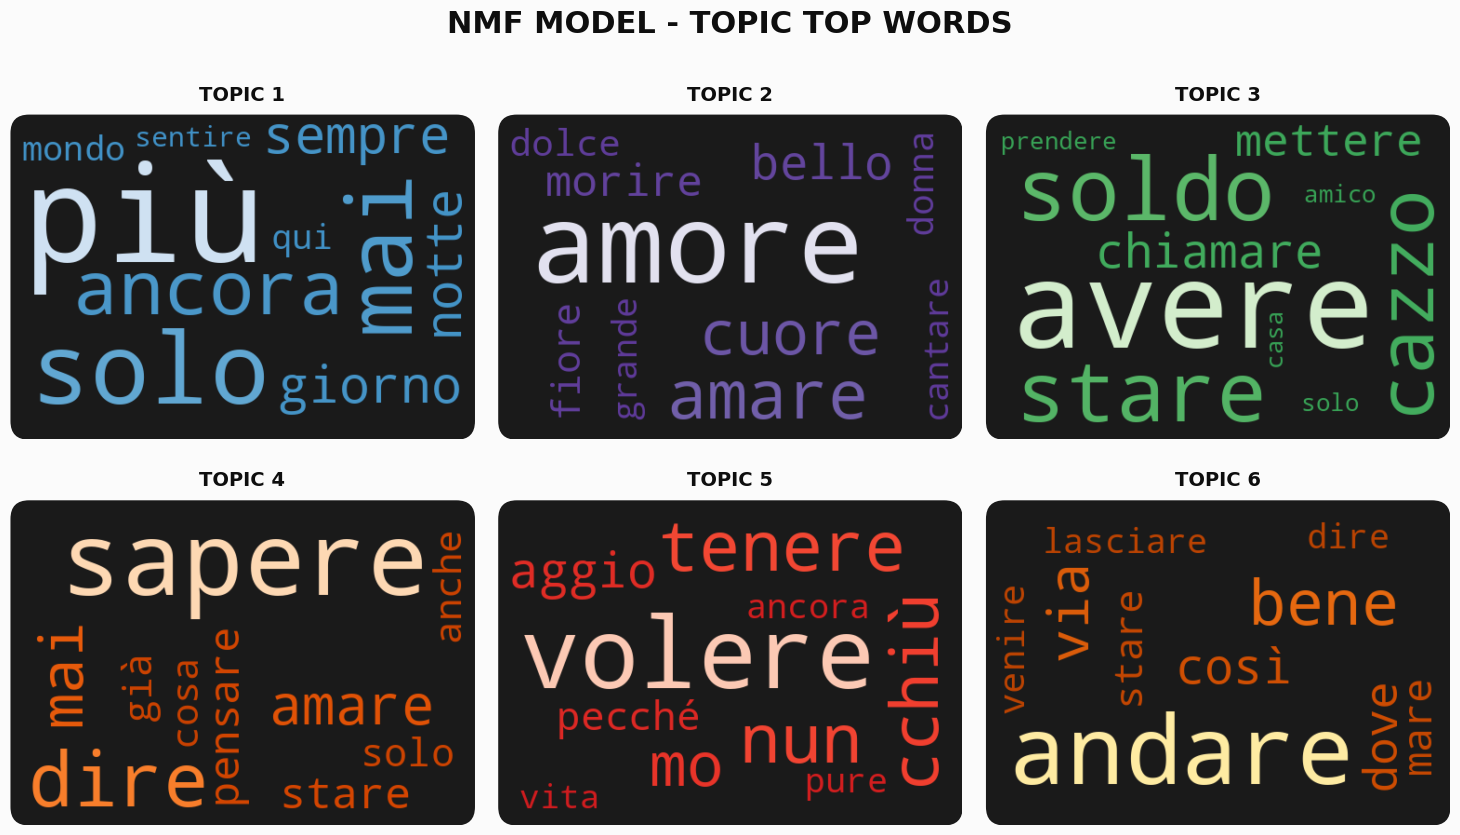

In [16]:
plot_hybrid_wordclouds(nmf_model, feature_names, NO_TOP_WORDS, model_name="NMF")

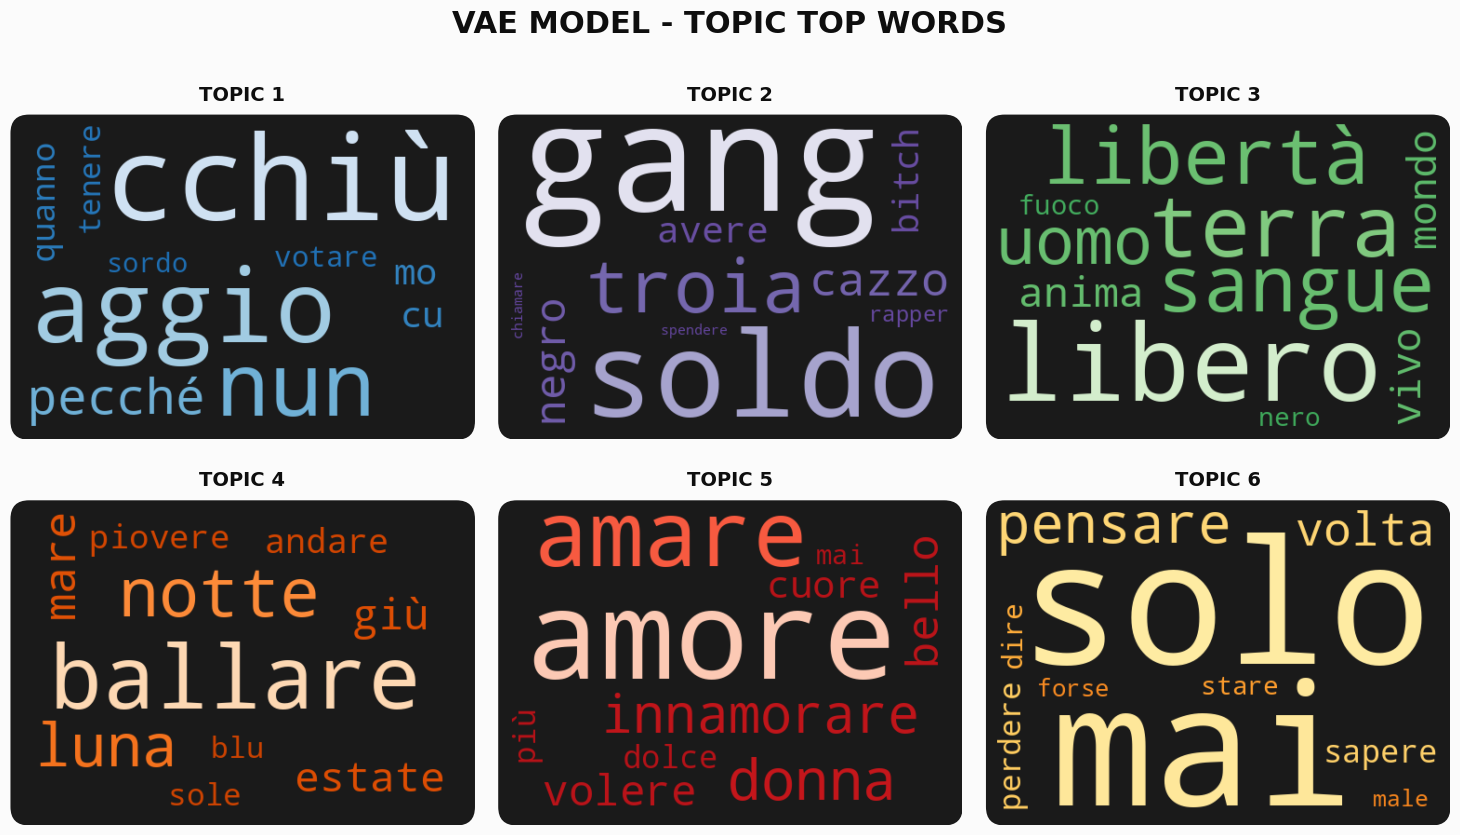

In [17]:
import numpy as np

# Extract the beta matrix 
beta = model.decoder.weight.data.cpu().numpy().T 

# Neural network weights (logits) can be negative. We use the exponential function (np.exp) 
# to transform them into strictly positive relative frequencies, making them perfect for WordCloud.
beta_positive = np.exp(beta)

# We create an empty class and assign it the ".components_" attribute 
# so your plotting function will think it's dealing with a standard Scikit-Learn model
class DummyModel:
    pass

vae_dummy_model = DummyModel()
vae_dummy_model.components_ = beta_positive

plot_hybrid_wordclouds(
    model=vae_dummy_model, 
    feature_names=feature_names, 
    no_top_words=NO_TOP_WORDS, 
    model_name="VAE",
    num_topics=NUM_TOPICS
)